In [1]:

# importing the data(no added coloumn)
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('india2.csv')
import pandas as pd

pd.set_option("display.max_columns", None) 
pd.set_option("display.width", 200)        
pd.set_option("display.max_colwidth", None)  
pd.set_option("display.max_colwidth", 50)   

In [2]:
# Count null values per column
df.isnull().sum()


video_id          0
trending_date     0
title             0
channel_title     0
category_id       0
publish_time      0
views             4
likes            14
dislikes          0
comment_count    37
dtype: int64

In [12]:
#mean hai
mean_views = df['views'].mean()

# old way (unsafe in future Pandas)
# df['views'].fillna(mean_views, inplace=True)

# new safe way
df['views'] = df['views'].fillna(mean_views)

print("after handeliing\n")
df[["channel_title","views"]].head(10)

after handeliing



,channel_title,views
0,Lokdhun Punjabi,1096327.0
1,HJ NEWS,590101.0
2,TFPC,473988.0
3,Eruma Saani,1242680.0
4,Filmylooks,464015.0
5,Dil Raju,6106669.0
6,Speed Records,5718766.0
7,T-Series,10588371.0
8,Top Telugu Media,118223.0
9,Jump Cuts,969030.0


In [13]:
#median
median_likes = df['likes'].median()
df['likes'] = df['likes'].fillna(median_likes)

print("after handeliing\n")
df[["channel_title","views"]].head(10)

after handeliing



,channel_title,views
0,Lokdhun Punjabi,1096327.0
1,HJ NEWS,590101.0
2,TFPC,473988.0
3,Eruma Saani,1242680.0
4,Filmylooks,464015.0
5,Dil Raju,6106669.0
6,Speed Records,5718766.0
7,T-Series,10588371.0
8,Top Telugu Media,118223.0
9,Jump Cuts,969030.0


In [14]:
#  mode 
mode_comments = df['comment_count'].mode()[0]

df['comment_count'] = df['comment_count'].fillna(mode_comments)
print("After handling nulls in comment_count:\n")
df[["channel_title", "comment_count"]].head(10)

After handling nulls in comment_count:



,channel_title,comment_count
0,Lokdhun Punjabi,882.0
1,HJ NEWS,0.0
2,TFPC,149.0
3,Eruma Saani,2684.0
4,Filmylooks,66.0
5,Dil Raju,4763.0
6,Speed Records,8063.0
7,T-Series,10847.0
8,Top Telugu Media,23.0
9,Jump Cuts,2404.0


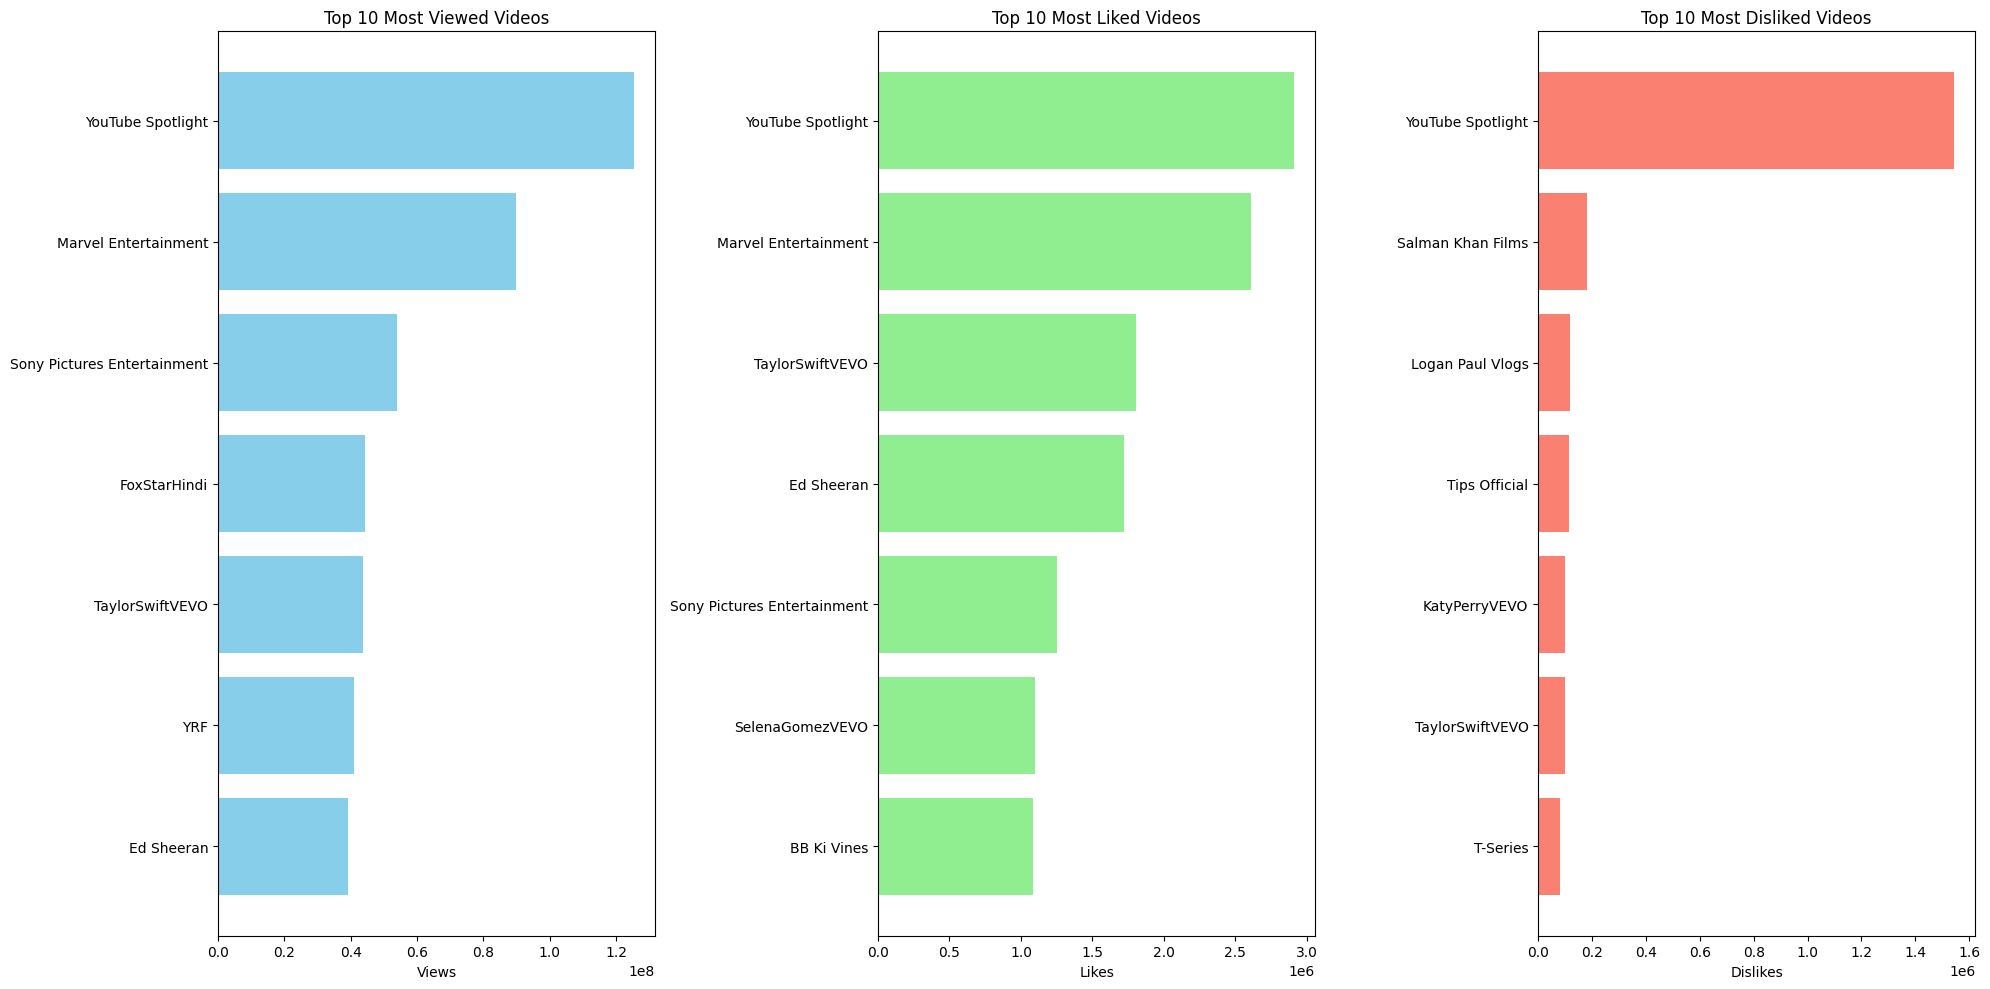

In [3]:

# ================ TOP 10 MOST VIEWED ================= #
max_views = df.groupby(["video_id", "channel_title"])["views"].max().reset_index()
sorted_videos = max_views.sort_values(by="views", ascending=False).head(10)

# ================= TOP 10 MOST LIKED ================= #
top_liked = (
    df.sort_values(by="likes", ascending=False)
    .drop_duplicates("video_id")
    .head(10)
)

# ================= TOP 10 MOST DISLIKED ================= #
top_disliked = (
    df.sort_values(by="dislikes", ascending=False)
    .drop_duplicates("video_id")
    .head(10)
)

# ================= PLOT ================= #
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# Views
axes[0].barh(sorted_videos["channel_title"], sorted_videos["views"], color="skyblue")
axes[0].set_title("Top 10 Most Viewed Videos")
axes[0].set_xlabel("Views")
axes[0].invert_yaxis()

# Likes
axes[1].barh(top_liked["channel_title"], top_liked["likes"], color="lightgreen")
axes[1].set_title("Top 10 Most Liked Videos")
axes[1].set_xlabel("Likes")
axes[1].invert_yaxis()

# Dislikes
axes[2].barh(top_disliked["channel_title"], top_disliked["dislikes"], color="salmon")
axes[2].set_title("Top 10 Most Disliked Videos")
axes[2].set_xlabel("Dislikes")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


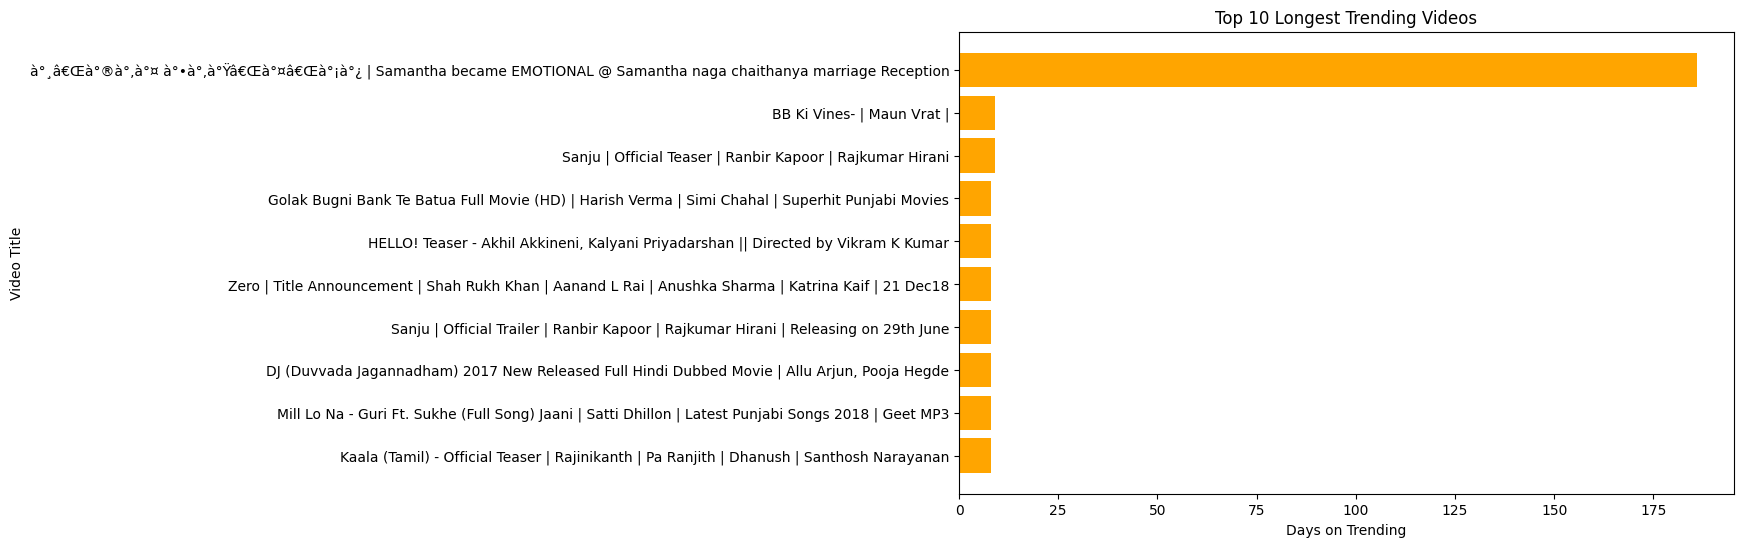

In [4]:
#longest trending videos
pd.set_option("display.max_columns", None)  
pd.set_option("display.width", 200)       
pd.set_option("display.max_colwidth", None)  

df["trending_date"] = pd.to_datetime(df["trending_date"], format="%y.%d.%m", errors="coerce")

trend_duration = df.groupby("video_id")["trending_date"].nunique().reset_index()
trend_duration.columns = ["video_id", "days_on_trending"]

trend_duration = trend_duration.merge(
    df[["video_id", "title", "channel_title"]].drop_duplicates("video_id"),
    on="video_id",
    how="left"
)
trend_duration.sort_values(by="days_on_trending", ascending=False).head(10)

import matplotlib.pyplot as plt

top_trend = trend_duration.sort_values(by="days_on_trending", ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.barh(top_trend["title"], top_trend["days_on_trending"], color="orange")
plt.xlabel("Days on Trending")
plt.ylabel("Video Title")
plt.title("Top 10 Longest Trending Videos")
plt.gca().invert_yaxis() 
plt.show()

In [5]:
#loading catogories noww

In [6]:

import json
pd.set_option("display.max_colwidth", 50)      

#  Loading JSON
with open("category.json", "r") as f:
    data = json.load(f)

# Build mapping 
category_dict = {int(item["id"]): item["snippet"]["title"] for item in data["items"]}

# Map category_id to human-readable Category 
df["Category"] = df["category_id"].map(category_dict)

df[["video_id", "title", "channel_title", "category_id", "Category"]].head(10)

,video_id,title,channel_title,category_id,Category
0,kzwfHumJyYc,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,Film & Animation
1,zUZ1z7FwLc8,"à¤ªà¥€à¤°à¤¿à¤¯à¤¡à¥à¤¸ à¤•à¥‡ à¤¸à¤®à¤¯, à¤ª...",HJ NEWS,25,News & Politics
2,10L1hZ9qa58,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,Entertainment
3,N1vE8iiEg64,Eruma Saani | Tamil vs English,Eruma Saani,23,Comedy
4,kJzGH0PVQHQ,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,Entertainment
5,il_pSa5l98w,"MCA (Middle Class Abbayi) TEASER - Nani,Sai Pa...",Dil Raju,24,Entertainment
6,7MxiQ4v0EnE,Daang ( Full Video ) | Mankirt Aulakh | Sukh S...,Speed Records,10,Music
7,c64I9HNpiOY,Padmavati : Ek Dil Ek Jaan Video Song | Deepik...,T-Series,10,Music
8,KObFEYCaRx8,Chiranjeevi in Naga Chaitanya - Samantha Recep...,Top Telugu Media,24,Entertainment
9,g8QsfJhFpjY,New bike vs Old bike - the reality,Jump Cuts,24,Entertainment


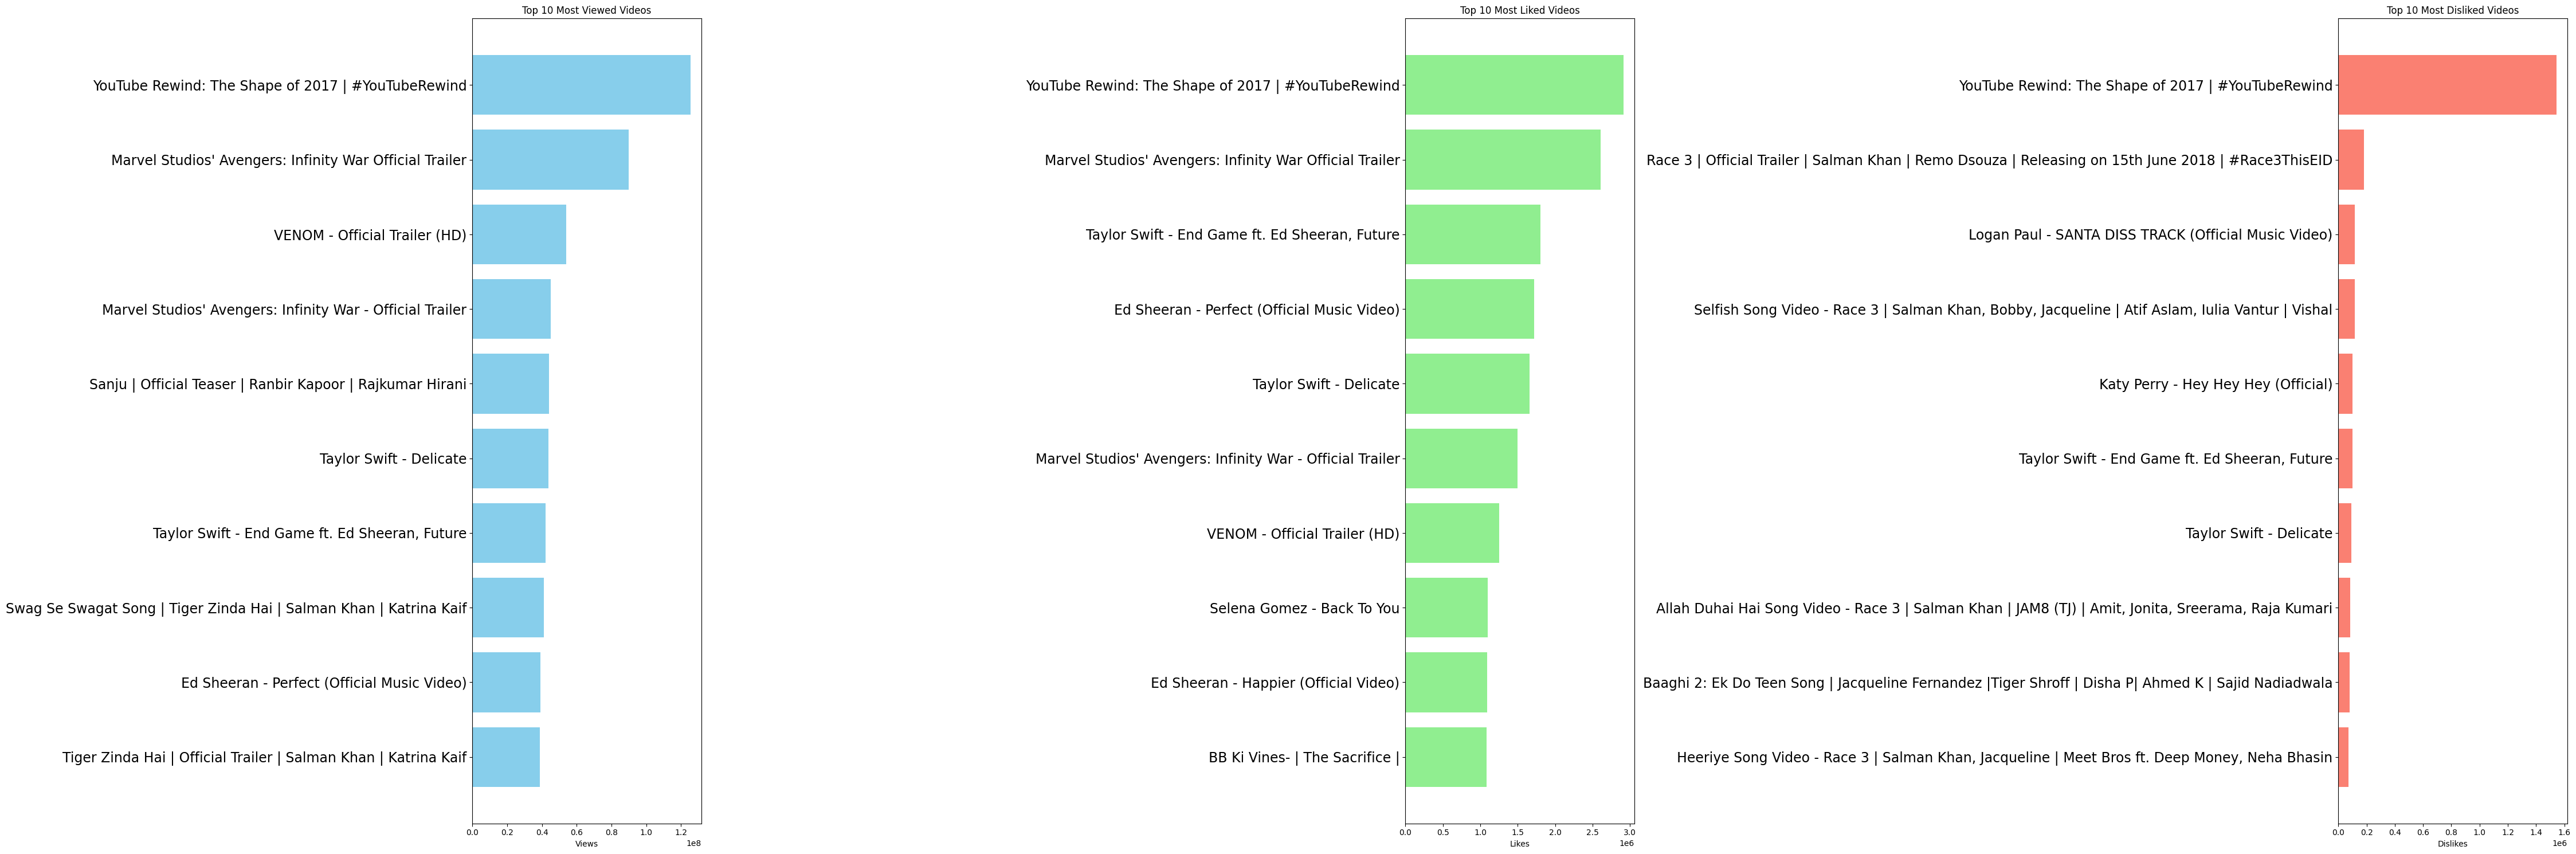

In [7]:



# ================= TOP 10 MOST VIEWED ================= #
max_views = df.groupby(["video_id", "title", "channel_title"])["views"].max().reset_index()
sorted_videos = max_views.sort_values(by="views", ascending=False).head(10)

# ================= TOP 10 MOST LIKED ================= #
top_liked = (
    df.sort_values(by="likes", ascending=False)
    .drop_duplicates("video_id")
    .head(10)
)

# ================= TOP 10 MOST DISLIKED ================= #
top_disliked = (
    df.sort_values(by="dislikes", ascending=False)
    .drop_duplicates("video_id")
    .head(10)
)

# ================= PLOT ================= #
fig, axes = plt.subplots(1, 3, figsize=(45, 15))

# Views
axes[0].barh(sorted_videos["title"], sorted_videos["views"], color="skyblue")
axes[0].set_title("Top 10 Most Viewed Videos")
axes[0].set_xlabel("Views")
axes[0].invert_yaxis()

# Likes
axes[1].barh(top_liked["title"], top_liked["likes"], color="lightgreen")
axes[1].set_title("Top 10 Most Liked Videos")
axes[1].set_xlabel("Likes")
axes[1].invert_yaxis()

# Dislikes
axes[2].barh(top_disliked["title"], top_disliked["dislikes"], color="salmon")
axes[2].set_title("Top 10 Most Disliked Videos")
axes[2].set_xlabel("Dislikes")
axes[2].invert_yaxis()

for ax in axes:
    ax.tick_params(axis='y', labelsize=17)  # video names
    ax.tick_params(axis='x', labelsize=10)  # numbers


plt.tight_layout()
plt.show()


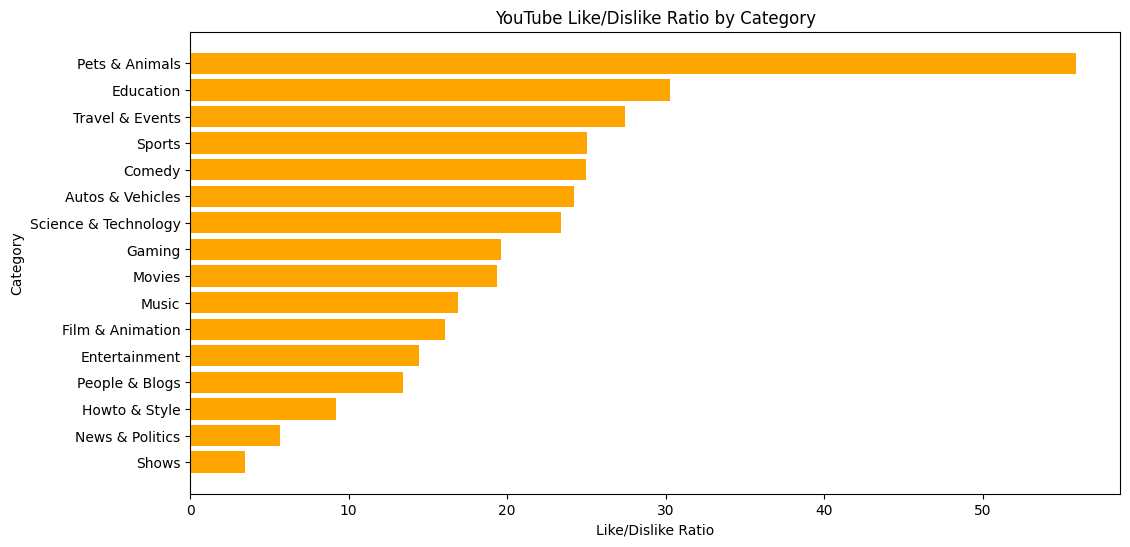

,Category,likes,dislikes,like_dislike_ratio
11,Pets & Animals,362534.0,6488,55.869009
2,Education,7471726.0,246667,30.290617
15,Travel & Events,16939.0,616,27.453809
14,Sports,32969986.0,1316379,25.045949
1,Comedy,174114686.0,6976508,24.957280
0,Autos & Vehicles,539571.0,22284,24.212295
12,Science & Technology,21395585.0,913603,23.418883
5,Gaming,6707728.0,341616,19.635229
7,Movies,662651.0,34182,19.385396
8,Music,254328536.0,15030992,16.920275


In [8]:
#like to dislike ratio
category_mapping = {}
for item in data["items"]:
    category_mapping[int(item["id"])] = item["snippet"]["title"]

# Map category_id → category name
df["Category"] = df["category_id"].map(category_mapping)


# Group by Category and sum likes and dislikes
category_stats = df.groupby("Category")[["likes", "dislikes"]].sum().reset_index()

# Calculate Like/Dislike ratio
category_stats["like_dislike_ratio"] = category_stats["likes"] / (category_stats["dislikes"] + 1)  

# Sort by ratio (descending)
category_stats = category_stats.sort_values(by="like_dislike_ratio", ascending=False)

# Plot
plt.figure(figsize=(12,6))
plt.barh(category_stats["Category"], category_stats["like_dislike_ratio"], color="orange")
plt.xlabel("Like/Dislike Ratio")
plt.ylabel("Category")
plt.title("YouTube Like/Dislike Ratio by Category")
plt.gca().invert_yaxis()

plt.show()
category_stats


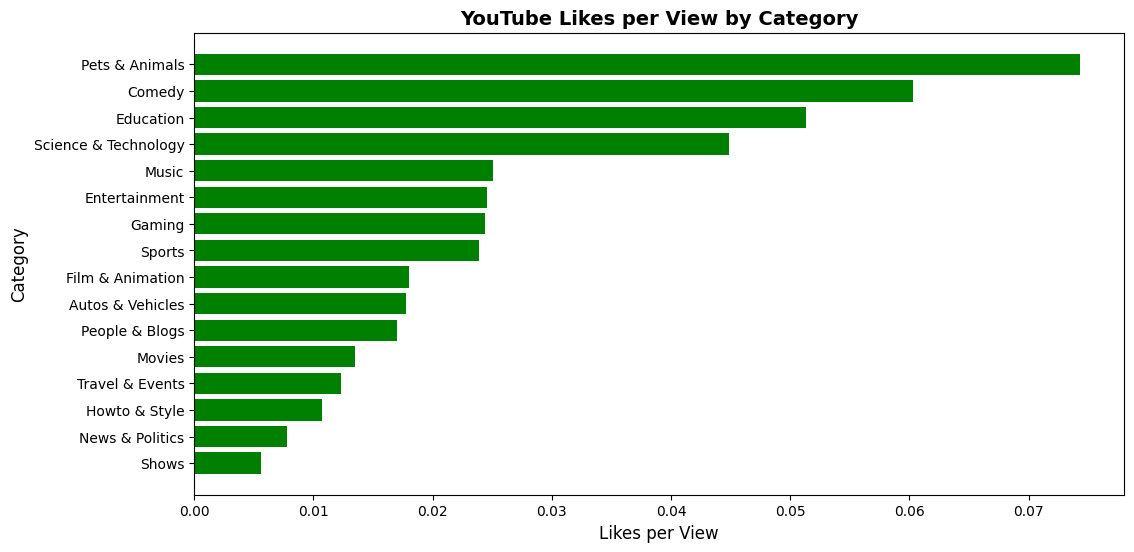

In [9]:
#likes per View (engagement from positive reaction)
df_category = df.groupby("Category")[["views", "likes"]].sum().reset_index()

# Likes per View
df_category["likes_per_view"] = df_category["likes"] / df_category["views"]

# Sort descending
df_category = df_category.sort_values(by="likes_per_view", ascending=False)
df_category[["Category", "views", "likes", "likes_per_view"]]

import matplotlib.pyplot as plt

# Plot Likes per View
plt.figure(figsize=(12,6))
plt.barh(df_category["Category"], df_category["likes_per_view"], color="green")

plt.xlabel("Likes per View", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.title("YouTube Likes per View by Category", fontsize=14, fontweight="bold")

# Invert y-axis so highest is at top
plt.gca().invert_yaxis()

plt.show()


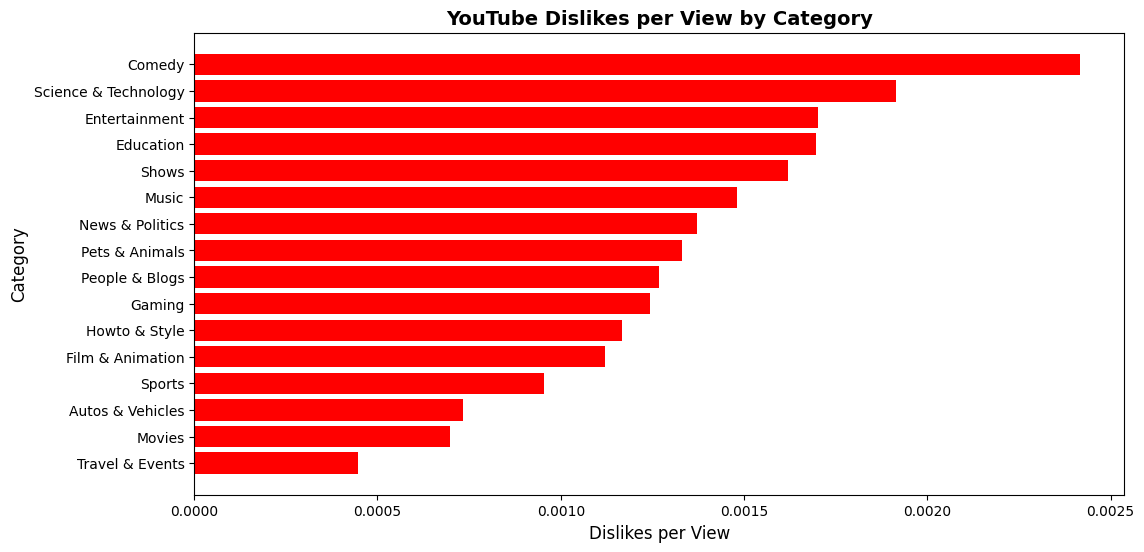

In [10]:
#Dislikes per View (negative reception)
df_category = df.groupby("Category")[["views", "dislikes"]].sum().reset_index()

# Dislikes per View
df_category["dislikes_per_view"] = df_category["dislikes"] / df_category["views"]

# Sort descending
df_category = df_category.sort_values(by="dislikes_per_view", ascending=False)
df_category[["Category", "views", "dislikes", "dislikes_per_view"]]

# Plot Dislikes per View
plt.figure(figsize=(12,6))
plt.barh(df_category["Category"], df_category["dislikes_per_view"], color="red")

plt.xlabel("Dislikes per View", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.title("YouTube Dislikes per View by Category", fontsize=14, fontweight="bold")

# Invert y-axis so highest is at top
plt.gca().invert_yaxis()

plt.show()


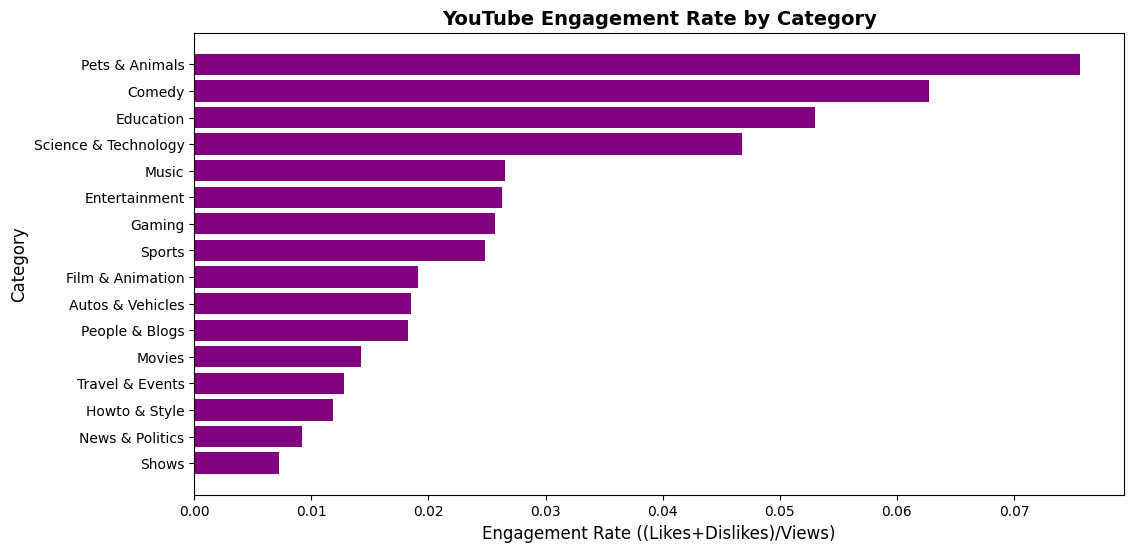

In [11]:
#Engagement Rate ((Likes+Dislikes)/Views)
df_category = df.groupby("Category")[["views", "likes", "dislikes"]].sum().reset_index()

# Engagement Rate
df_category["engagement_rate"] = (df_category["likes"] + df_category["dislikes"]) / df_category["views"]

# Sort descending
df_category = df_category.sort_values(by="engagement_rate", ascending=False)
df_category[["Category", "views", "likes", "dislikes", "engagement_rate"]]


# Plot Engagement Rate
plt.figure(figsize=(12,6))
plt.barh(df_category["Category"], df_category["engagement_rate"], color="purple")

plt.xlabel("Engagement Rate ((Likes+Dislikes)/Views)", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.title("YouTube Engagement Rate by Category", fontsize=14, fontweight="bold")

# Show highest at the top
plt.gca().invert_yaxis()

plt.show()